In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [2]:
df = pd.read_csv('data_smartphone.csv')
# 3260 rows and 20 columns
# object, int64 and float 64 data types
#missing values in has_finegrprints and has_nfc and has_5g and num_core and refresh_rate(hz) 
# 33 unique brands

<Axes: >

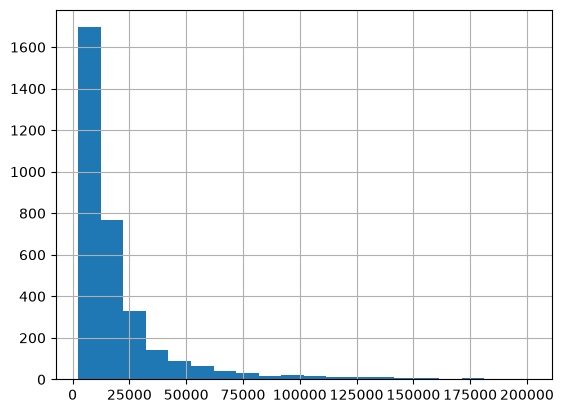

In [3]:
df['Price'].hist(bins=20)

<Axes: >

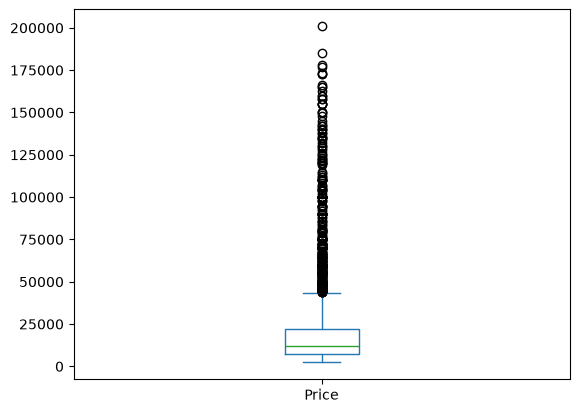

In [4]:
df['Price'].plot(kind = 'box')

obs 5 is that the data is right skwewed


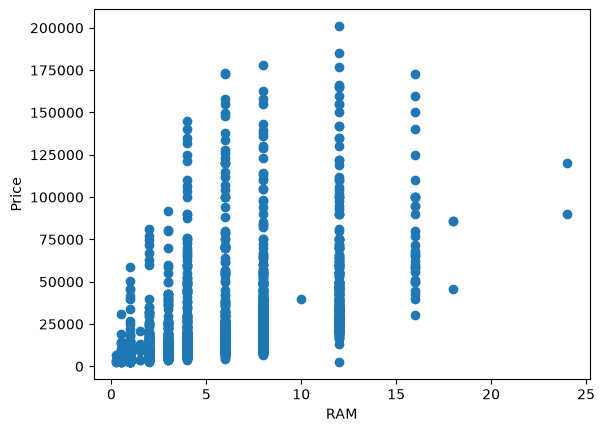

In [5]:
x = df["RAM"]
y = df["Price"]
plt.scatter(x, y)
plt.xlabel("RAM")
plt.ylabel("Price")
plt.show()

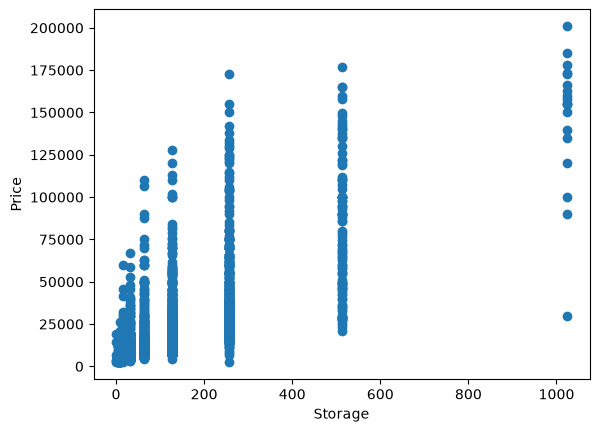

In [6]:
x1 = df["storage"]
y1 = df["Price"]
plt.scatter(x1, y1)
plt.xlabel("Storage")
plt.ylabel("Price")
plt.show()

#7 the relation between storage and price is fairly weak


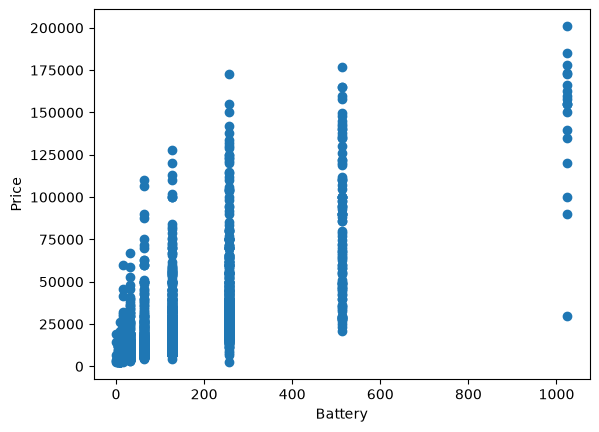

In [7]:
x2 = df["Battery_cap"]
y1 = df["Price"]
plt.scatter(x1, y1)
plt.xlabel("Battery")
plt.ylabel("Price")
plt.show()

#8 the battery to price relation is also not very good

In [8]:
df.groupby("brand_name")["Price"].mean()

brand_name
Other        12717.822300
apple        85701.591667
asus         28299.740260
coolpad       7271.227273
gionee        8849.027027
google       52165.500000
honor        17298.157895
htc          21315.483871
ikall         5904.690722
infinix      12382.370000
intex         5386.288136
iqoo         30167.776119
itel          6180.229508
karbonn       5101.756098
lava          8116.709402
lenovo       11338.474576
lg           19750.772727
lyf           4847.500000
micromax      7295.350000
moto         11245.388889
motorola     29700.914286
nokia        12428.541667
oneplus      37159.571429
oppo         20508.068966
panasonic     7401.000000
poco         14620.300000
realme       16156.370861
samsung      32697.488889
sony         22749.823529
tecno        13416.344538
vivo         22398.515021
xiaomi       15412.766393
xolo          8561.475000
Name: Price, dtype: float64

In [9]:
df.groupby("processor_brand")["Price"].mean().sort_values(ascending = True)

processor_brand
spreadtrum       4724.811765
quad             5074.602151
tru-mediatek     7065.272727
broadcom         8100.571429
unisoc           8353.659091
mediatek        13929.117775
st-ericsson     13990.000000
nvidia          14832.000000
huawei          16500.000000
hisilicon       17608.324324
intel           17763.400000
samsung         24514.833333
snapdragon      26033.965877
google          77625.666667
apple           85701.591667
Name: Price, dtype: float64

In [10]:
x = df.drop("Price", axis = 1)
y = df["Price"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
x_train.shape
x_test.shape
y_train.shape
y_test.shape

(652,)

In [14]:
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [15]:
x_train.select_dtypes(include='object').columns

C:\Users\Ishaan\AppData\Local\Temp\ipykernel_28148\3057327729.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_train.select_dtypes(include='object').columns


Index(['brand_name', 'Name', 'OS', 'has_fast_charging', 'has_fingerprints',
       'has_nfc', 'has_5g', 'processor_brand', 'display_types'],
      dtype='str')

In [16]:
Cat_col = x_train.select_dtypes(include='object').columns

C:\Users\Ishaan\AppData\Local\Temp\ipykernel_28148\2927453030.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Cat_col = x_train.select_dtypes(include='object').columns


In [17]:
encoder.fit(x_train[Cat_col])

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [18]:
x_train_encoded = encoder.transform(x_train[Cat_col])

In [19]:
x_train_encoded.shape

(2608, 2675)

In [20]:
x_train = x_train.drop(columns=['Name'])
x_test = x_test.drop(columns=['Name'])
x_train = x_train.drop(columns=["refresh_rate(hz)"])
x_test = x_test.drop(columns=["refresh_rate(hz)"])

In [21]:
cat_cols = x_train.select_dtypes(include='object').columns
encoder.fit(x_train[cat_cols])

C:\Users\Ishaan\AppData\Local\Temp\ipykernel_28148\1177473253.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(include='object').columns


,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [22]:
x_train_encoded = encoder.transform(x_train[cat_cols])

In [23]:
x_train_encoded.shape

(2608, 67)

In [24]:
x_train.shape

(2608, 17)

In [36]:
median_num_core = x_train["num_core"].median()
x_train["num_core"] = x_train["num_core"].fillna(median_num_core)
x_test["num_core"] = x_test["num_core"].fillna(median_num_core)

In [37]:
num_cols = x_train.select_dtypes(exclude='object').reset_index(drop=True)

In [38]:
x_train_final = pd.concat(
    [num_cols, pd.DataFrame(
    x_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)],
    axis = 1
)

In [39]:
x_train_final.shape

(2608, 76)

In [40]:
x_test_encoded = encoder.transform(x_test[cat_cols])
num_cols_test = x_test.select_dtypes(exclude='object')
num_cols_test = num_cols_test.reset_index(drop = True)


In [41]:
x_test_final = pd.concat(
    [num_cols_test, pd.DataFrame(
    x_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)],
    axis = 1
)

In [42]:
x_train["num_core"].isna().sum()
x_test["num_core"].isna().sum()

np.int64(0)

In [43]:
x_train_final.isna().sum().sort_values(ascending=False)

RAM                             0
storage                         0
Battery_cap                     0
num_core                        0
primery_rear_camera             0
                               ..
display_types_amoled display    0
display_types_lcd display       0
display_types_oled display      0
display_types_other display     0
display_types_tft display       0
Length: 76, dtype: int64

In [44]:
model = LinearRegression()
model.fit(x_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](76,)","[ 1193.21, 92.28, -0.75,..., 7493.2 ,-6656.39,-1589.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](76,)","['RAM','storage','Battery_cap',...,'display_types_oled display', 'display_types_other display','display_types_tft display']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.131e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,76
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(64)


In [45]:
y_pred = model.predict(x_test_final)

In [46]:
print(y_pred[:10])

[21887.25074736  9949.01058694 10954.89507661  5652.73429558
  5260.64491672 20981.96263696 17327.71720224 61411.08508553
 10937.84014339  8554.38230306]


In [47]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
1569,15999,21887.250747
134,10999,9949.010587
844,4999,10954.895077
2247,7999,5652.734296
3031,6799,5260.644917
291,14499,20981.962637
2980,17999,17327.717202
478,27999,61411.085086
2183,5499,10937.840143
2063,12490,8554.382303


In [48]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 7150.811632721525


In [50]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

RMSE: 11652.574139653068


In [54]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.7224574427553034
